# Imports

In [7]:
# Import necessary libraries

import torch
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
import pandas as pd
#from sklearn.metrics import confusion_matrix, classification_report
import os
#import json

# Additional debugging utilities
import pdb  # Python Debugger
import logging

# Configure logging for better debugging output
logging.basicConfig(level=logging.DEBUG)

print("Imports completed successfully!")

Imports completed successfully!


In [4]:
# Import necessary libraries
from ollama import chat

# Define the model and messages
model = 'glm-ocr:latest'
messages = [{'role': 'user', 'content': 'Hello!'}]

# Send the message to the model and get a response
response = chat(model=model, messages=messages)

# Print the response from the model
print(response.message.content)

Hello!


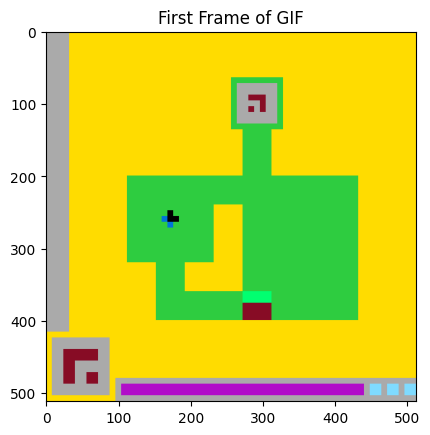

In [ ]:
# Import necessary libraries for image processing and encoding
import numpy as np
from PIL import Image
import io
import base64
import subprocess

def image_to_base64(image_pil):
    with io.BytesIO() as buffer:
        image_pil.save(buffer, format="PNG")
        img_str = base64.b64encode(buffer.getvalue()).decode('utf-8')
    return img_str

# Load the GIF file
gif_path = '/home/lavolpe/Bureau/Kaggle/ARC-AGI-3/results/gifs/variantA_ls20.gif'  # Replace with your GIF file path
gif_frames = Image.open(gif_path)
first_frame_image = gif_frames.convert('RGBA')  # Convert to RGBA for proper handling

# Display the first frame using matplotlib for verification (optional)
import matplotlib.pyplot as plt
plt.imshow(first_frame_image)
plt.title("First Frame of GIF")
plt.show()

# Save the extracted image temporarily on disk for use with ollama CLI command
temp_image_path = 'temp_first_frame.png'
first_frame_image.save(temp_image_path)

# Use subprocess to call the ollama run command
command = ["ollama", "run", "glm-ocr", "Figure Recognition:", temp_image_path]
result = subprocess.run(command, capture_output=True, text=True)

print(result.stdout)  # Print standard output from ollama command

# If needed, print error messages as well
if result.stderr:
    print("Errors:")
    print(result.stderr)